# PyFue Demo

Training linear regression model to predict absolute deviations...
Generating predictions for absolute deviations using the trained linear model...


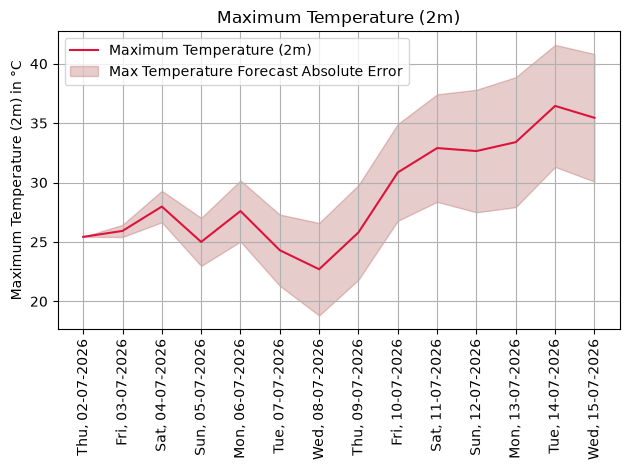

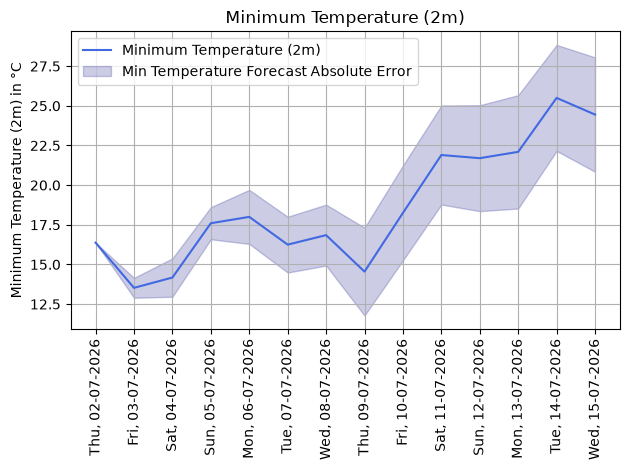

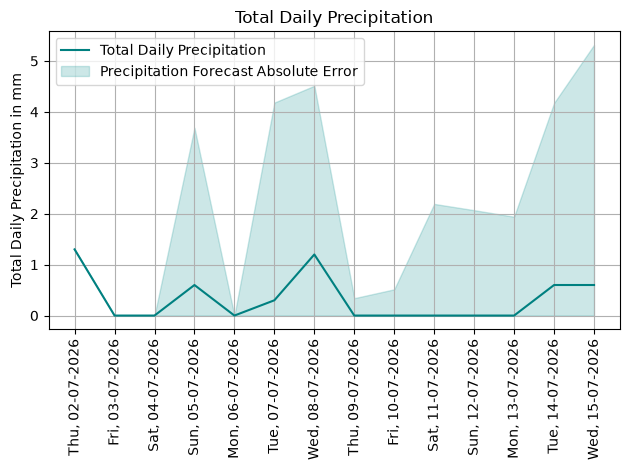

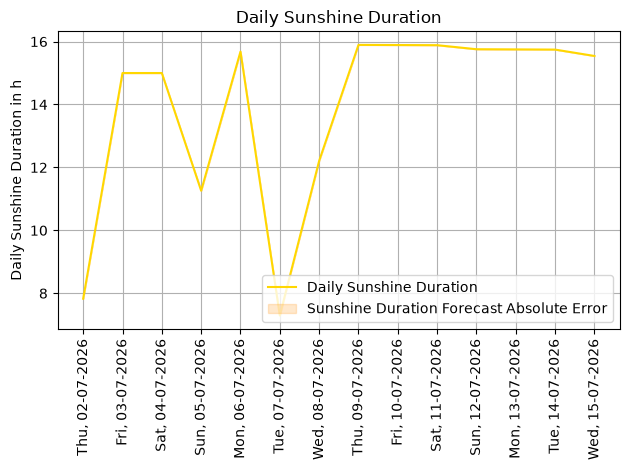

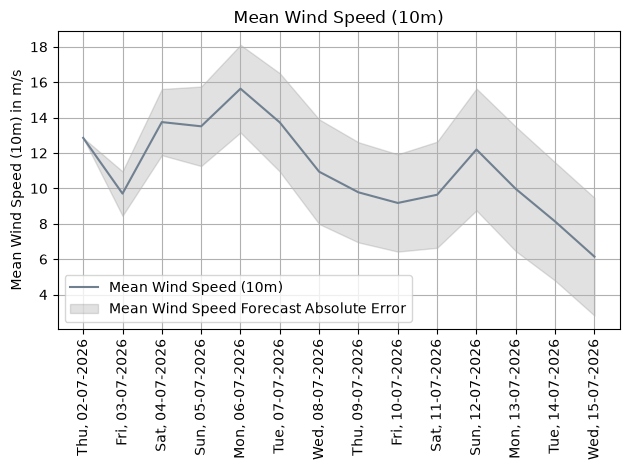

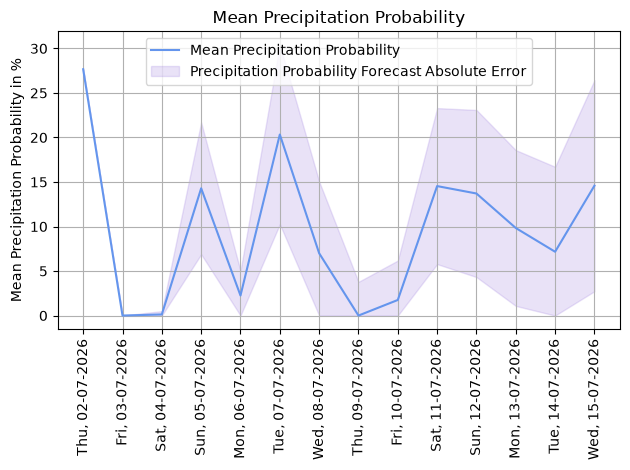

In [ ]:
import pandas as pd

from fue import Config, Data, Forecast
from fue.models import LinearUncertaintyModel

# ==========================================
# 1. Ingest and Pool Multi-City Datasets
# ==========================================
data = Data()
data.read_raw()

all_city_records = []

config = Config()
for city in config.city_coordinates.keys():
    # Use val_fraction=0.0 here so we gather 100% of the city data into a list first
    city_df, _ = data.generate_dataset(location_name=city, val_fraction=0.0)
    all_city_records.append(city_df)

# Combine datasets vertically into one unified DataFrame (~1000+ total rows)
combined_dataset = pd.concat(all_city_records, ignore_index=True)


# ==========================================
# 2. Instantiate Model and Configure Columns
# ==========================================

# Explicitly ensure location markers are part of features so the network adjusts to microclimates
feature_columns = ["latitude", "longitude"] + config.default_feature_columns
target_columns = config.default_target_columns  # .remove("abs_diff__sunshine_duration")


model = LinearUncertaintyModel(config)  # For demonstration, we can also use the linear model
model.fit(combined_dataset, feature_columns, target_columns)
F = Forecast()
F.fetch_forecast(location_name="aachen", forecast_days=14)
F.compute_uncertainties(model)
F.plot(target_variables=target_columns)